In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [4]:
import glob

In [16]:
import re

In [3]:
methods = ['cis','fci']
molecules = ['heh+','h2']
bases = ['sto-3g','3-21g','6-31g','6-31gss']

In [10]:
alldata = {}

In [47]:
for meth in methods:
    for mol in molecules:
        for basis in bases:
            path = './pinngpu/newFF/'
            pattern = meth + '_' + mol + '_' + basis + '*'
            files = glob.glob(path + pattern)
            # first cull the smaxes
            allsmax = []
            for s in files:
                m = re.search(r'_(\d+)_(\d+)\.txt$', s)
                _, smax = map(int, m.groups())
                allsmax.append(smax)
            
            allsmax = list(set(allsmax))
            # now assemble all the data
            for smax in allsmax:
                pattern = meth + '_' + mol + '_' + basis + '_0.010000_*_' + str(smax) + '.txt'
                files = glob.glob(path + pattern)
                if files==[]:
                    continue
                data = []
                for s in files:
                    m = re.search(r'_(\d+)_(\d+)\.txt$', s)
                    delay, _ = map(int, m.groups())
                    data.append([ delay, np.loadtxt(s) ])
                dataarray = np.array(data)
                dataarray = dataarray[np.argsort(dataarray[:, 0])]
                alldata[(meth, mol, basis, smax)] = dataarray
                
                

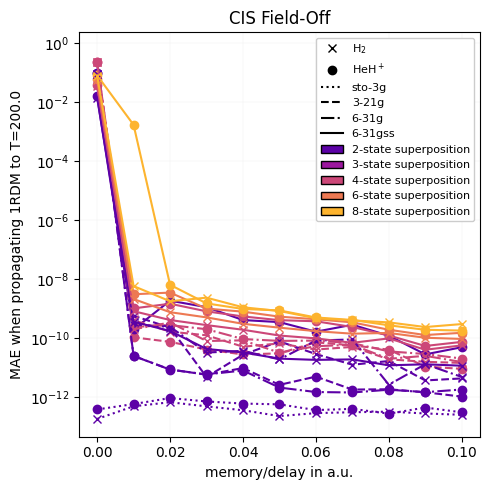

In [76]:
# try plasma colormap
# see https://matplotlib.org/stable/gallery/color/colormap_reference.html
# after this, cmap(0.5) will be the middle color in the color map
# also see https://matplotlib.org/stable/gallery/color/named_colors.html
cmap = matplotlib.colormaps['plasma']
cvals = np.linspace(0,1,7)[1:-1]

mymap = {}
mymap[2] = 0
mymap[3] = 1
mymap[4] = 2
mymap[6] = 3
mymap[8] = 4

plt.figure(figsize=(5,5))

mysize = 4.5

dt = 0.01

valsU = []
valsL = []

for mol in molecules:
    if mol=='h2':
        mrk = 'x'
    else:
        mrk = 'o'
    for basis in bases:
        if basis=='sto-3g':
            ls = ':'
        elif basis=='3-21g':
            ls = '--'
        elif basis=='6-31g':
            ls = '-.'
        else:
            ls = '-'
        for j in [2,3,4,6,8]:
            if ('cis', mol, basis, j) in alldata:
                yvals = alldata[('cis', mol, basis, j)]
                if len(yvals.shape)==1 and yvals.shape[0]==0:
                    continue
                valsU.append(np.max(yvals[:,1]))
                valsL.append(np.min(yvals[:,1]))
                plt.semilogy( dt*yvals[:,0], yvals[:,1], marker=mrk, linestyle=ls, color=cmap(cvals[mymap[j]]) )    

custom_handles = [
    # Molecules
    Line2D([0], [0], color='black', marker='x', linestyle='None', label=f"H$_2$"),
    Line2D([0], [0], color='black', marker='o', linestyle='None', label=f"HeH$^+$"),
    
    # Basis Sets
    Line2D([0], [0], color='black', linestyle=':', label='sto-3g'),
    Line2D([0], [0], color='black', linestyle='--', label='3-21g'),
    Line2D([0], [0], color='black', linestyle='-.', label='6-31g'),
    Line2D([0], [0], color='black', linestyle='-', label='6-31gss'),
    
    # "Colorbar" Patches
    Patch(facecolor=cmap(cvals[0]), edgecolor='black', label='2-state superposition'),
    Patch(facecolor=cmap(cvals[1]), edgecolor='black', label='3-state superposition'),
    Patch(facecolor=cmap(cvals[2]), edgecolor='black', label='4-state superposition'),
    Patch(facecolor=cmap(cvals[3]), edgecolor='black', label='6-state superposition'),
    Patch(facecolor=cmap(cvals[4]), edgecolor='black', label='8-state superposition'),
]

# Pass the updated handles to your legend
plt.legend(handles=custom_handles, loc="upper right", fontsize=8)


plt.xlabel('memory/delay in a.u.')
plt.ylabel('MAE when propagating 1RDM to T=200.0')
plt.ylim([np.min(valsL)*0.25, np.max(valsU)*10.1])

# Pass the custom handles directly to the legend
plt.grid(True, color='lightgrey', linewidth=0.1)
plt.legend(framealpha=1.0, facecolor='white',handles=custom_handles, loc="upper right", fontsize=8) 
plt.title(r'CIS Field-Off')
plt.tight_layout()
plt.savefig('CIS_FF.pdf')
plt.show()

[0, 1, 2, 3]


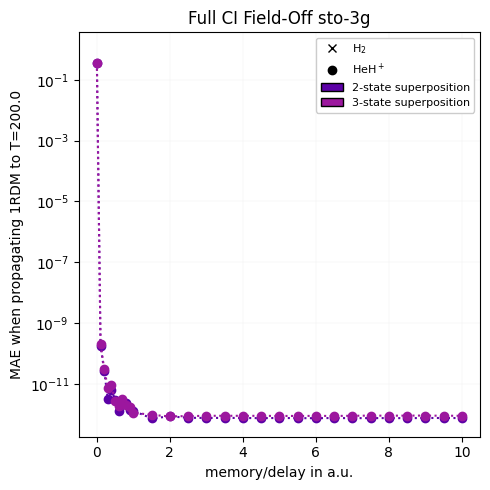

[0, 1, 2, 4, 5, 6]


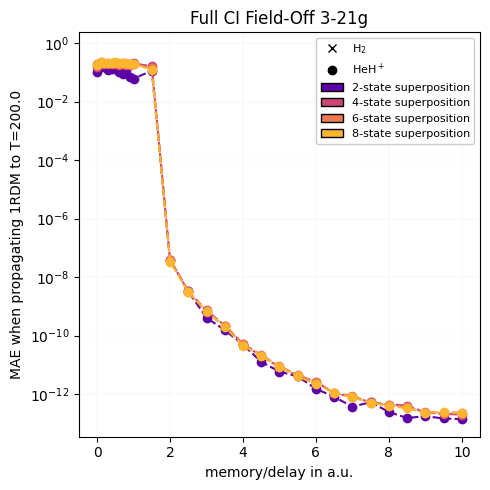

[0, 1, 2, 4, 5, 6]


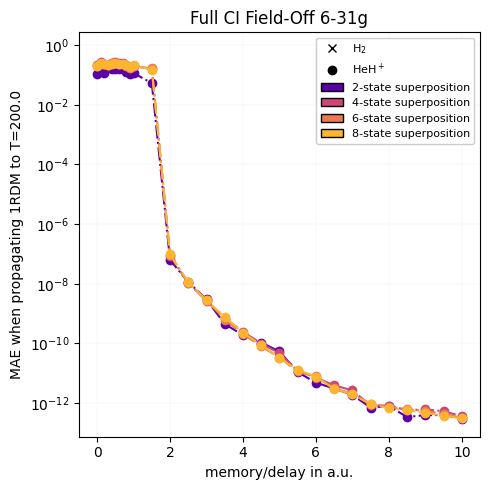

[0, 1, 2, 4, 5, 6]


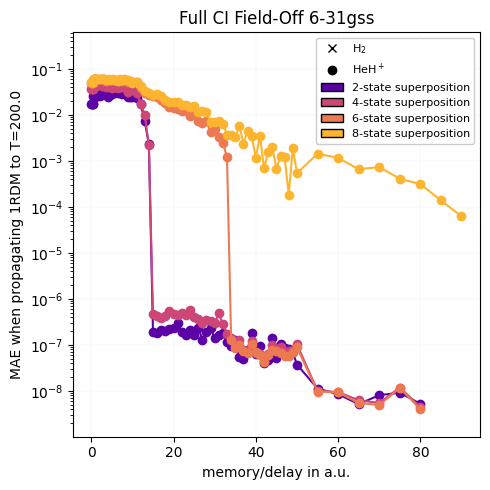

In [77]:
# try plasma colormap
# see https://matplotlib.org/stable/gallery/color/colormap_reference.html
# after this, cmap(0.5) will be the middle color in the color map
# also see https://matplotlib.org/stable/gallery/color/named_colors.html
cmap = matplotlib.colormaps['plasma']
cvals = np.linspace(0,1,7)[1:-1]

mymap = {}
mymap[2] = 0
mymap[3] = 1
mymap[4] = 2
mymap[6] = 3
mymap[8] = 4

mysize = 4.5

dt = 0.01

custom_handles = [
    # Molecules
    Line2D([0], [0], color='black', marker='x', linestyle='None', label=f"H$_2$"),
    Line2D([0], [0], color='black', marker='o', linestyle='None', label=f"HeH$^+$"),
    
    # "Colorbar" Patches
    Patch(facecolor=cmap(cvals[0]), edgecolor='black', label='2-state superposition'),
    Patch(facecolor=cmap(cvals[1]), edgecolor='black', label='3-state superposition'),
    Patch(facecolor=cmap(cvals[2]), edgecolor='black', label='4-state superposition'),
    Patch(facecolor=cmap(cvals[3]), edgecolor='black', label='6-state superposition'),
    Patch(facecolor=cmap(cvals[4]), edgecolor='black', label='8-state superposition'),
]

for basis in bases:
    plt.figure(figsize=(5,5))
    valsU = []
    valsL = []
    cvallist = [0,1]
    for mol in molecules:
        if mol=='h2':
            mrk = 'x'
        else:
            mrk = 'o'
            if basis=='sto-3g':
                ls = ':'
            elif basis=='3-21g':
                ls = '--'
            elif basis=='6-31g':
                ls = '-.'
            else:
                ls = '-'
            for j in [2,3,4,6,8]:
                if ('fci', mol, basis, j) in alldata:
                    yvals = alldata[('fci', mol, basis, j)]
                    if len(yvals.shape)==1 and yvals.shape[0]==0:
                        continue
                    cvallist.append(2+mymap[j])
                    valsU.append(np.max(yvals[:,1]))
                    valsL.append(np.min(yvals[:,1]))
                    plt.semilogy( dt*yvals[:,0], yvals[:,1], marker=mrk, linestyle=ls, color=cmap(cvals[mymap[j]]) )    
    # Pass the updated handles to your legend
    plt.legend(handles=custom_handles, loc="upper right", fontsize=8)
    plt.xlabel('memory/delay in a.u.')
    plt.ylabel('MAE when propagating 1RDM to T=200.0')
    plt.ylim([np.min(valsL)*0.25, np.max(valsU)*10.1])
    
    # Pass the custom handles directly to the legend
    plt.grid(True, color='lightgrey', linewidth=0.1)
    print(cvallist)
    myhandles = [custom_handles[j] for j in cvallist]
    plt.legend(framealpha=1.0, facecolor='white',handles=myhandles, loc="upper right", fontsize=8) 
    plt.title(r'Full CI Field-Off '+basis)
    plt.tight_layout()
    plt.savefig('FCI_FF_'+basis+'.pdf')
    plt.show()
    plt.close('all')